<div style="background: linear-gradient(90deg, #0f766e, #1e3a8a); padding: 30px; border-radius: 14px; text-align: center; color: white; box-shadow: 0px 4px 12px rgba(0,0,0,0.15);">

<h1 style="margin-bottom: 10px;">
📊 Exercise Project 1 – Linear Regression
</h1>

<h3 style="margin-top: 0; font-weight: 400;">
        ML Model: AI assistant usage
</h3>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/ayeshasal89/ai-assistant-usage-in-student-life-synthetic" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
AI Assistant Usage in Student Life
</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description, features and limitations</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    <b>Description:</b><br/>
    This dataset represents a fully synthetic simulation of how students use AI assistants in their academic life. 
    It contains 10,000 recorded sessions where students interact with tools such as ChatGPT or similar AI systems. 
    Each row represents a single usage session and captures behavioral, academic, and satisfaction-related information.
    The dataset is designed for exploratory data analysis (EDA), machine learning modeling, feature engineering practice,
    and educational analytics research. It contains no real personal data, making it safe for experimentation.
  </p>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    <b>Features:</b><br/>
    The dataset includes structured variables describing student profile, task type, and AI interaction outcomes:
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Student Level</b> – Academic stage (e.g., High School, Undergraduate, Graduate)</li>
    <li><b>Task Type</b> – Purpose of AI usage (Coding, Writing, Studying, Brainstorming, Research support, etc.)</li>
    <li><b>Session Duration</b> – Length of AI interaction session </li>
    <li><b>Frequency of Use</b> – How often the student uses AI tools</li>
    <li><b>AI Effectiveness Rating</b> – Perceived usefulness of the AI during the session</li>
    <li><b>Satisfaction Score</b> – Student satisfaction after the session</li>
    <li><b>Reuse Indicator</b> – Whether the student used the AI tool again later (Yes/No)</li>
  </ul>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li>Predicting <b>student satisfaction</b> </li>
  </ul>

  <p style="margin:12px 0 6px 0; font-size:16px; color:#fde68a;">
    <b>Limitations:</b><br/>
    • The dataset is fully synthetic and does not represent real student behavior.<br/>
    • Relationships between variables are simulated and may not capture real-world complexity.<br/>
    • Results obtained from machine learning experiments should be interpreted as practice outcomes, not real educational insights.
  </p>

  <p style="margin:12px 0 6px 0; font-size:16px; color:#fde68a;">
</div>


<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #856404; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #856404; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Don't skip ahead!
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


In [25]:
# Loading the required modules 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from skfeature.function.similarity_based import fisher_score
from skfeature.function.statistical_based import chi_square
from datetime import datetime

In [26]:
# Loading the dataset 
df = pd.read_csv('ai_assistant_usage_student_life.csv')
df


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9
...,...,...,...,...,...,...,...,...,...,...,...
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [27]:
# let's quickly see the first 5 rows of data
df.head(5)

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [28]:
# printing total no.s of rows and columns of whole dataset
df.shape

(10000, 11)

In [29]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


In [30]:
# getting statistical summary of the dataframe
df.describe()

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.846467,5.607500,3.479500,3.417780
std,13.897302,4.648764,0.991805,1.143331
min,0.030000,1.000000,1.000000,1.000000
25%,9.630000,2.000000,3.000000,2.600000
50%,16.650000,4.000000,4.000000,3.500000
75%,26.670000,8.000000,4.000000,4.400000
max,110.810000,39.000000,5.000000,5.000000


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

  <h2 style="margin:0; color:#f9fafb;">
    <b>Data Cleaning</b>
  </h2>

  <h4 style="margin:10px 0 0 0; color:#fde68a;">
    Handling missing values, removing duplicates, and properly encoding categorical variables
  </h4>

</div>

<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [31]:
# checking the nan values in the dataset
df.isna().sum() 

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

In [32]:
# checking duplicates in the dataset
duplicates = df.duplicated().sum()
print(duplicates)

0


In [33]:
# dropping this column as it is not useful for our analysis and prediction
df = df.drop('SessionID', axis=1)

In [34]:
# FILTERING A VALUE IN A COLUMN
# Here we are filtering the dataset to include 

# only rows where the "TaskType" column has the value "Writing".  
# df = df[df["TaskType"] == "Writing"] # uncomment this 
# the r squared value = 0.44

# df = df[df["TaskType"] == "Homework Help"]
# the r squared value = 0.38

# df = df[df["TaskType"] == "Studying"]
# the r squared value = 0.47

# when running with out any filtering the r squared value is 0.41


<div style="border: 4px solid #0f766e; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    FILTERING A VALUE IN A COLUMN OBSERVATION: 
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>When filtering only rows where the "TaskType" column has the value "Writing", then the R Squared value is: 0.44</li>
    <li>When filtering only rows where the "TaskType" column has the value "Homework Help", then the R Squared value is: 0.38</li>
    <li>When filtering only rows where the "TaskType" column has the value "Studying", then the R Squared value is: 0.47</li>
    <li>When not filtering any column, then the R Squared value is: 0.41</li>
    
  </ul>

</div>


<div style="border: 4px solid #0f766e; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
     OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>10,000 rows</b> and <b>11 columns</b>.</li>
    <li>There is not any null values in the dataset or duplicates in the dataset.</li>
    <p>Most columns are object and numeric, so we need prepare data carefully for our machine learning.
    I dropped SessionID column because it would not help with analysis or prediction.
    I kept only the rows where <b>"TaskType"</b> is <b>"Writing"</b>,
    This keeps the data more focused, and we can if it helps the model learn better or not if not then we can drop this is column. 
    </p>
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b> HANDLING ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


In [35]:
# making a separate column for month and year in session date
# Here we are converting the "SessionDate" column to a datetime format,
# extracting the month and year from it, and then formatting it as "YYYYMM" 
df['SessionDate'] = pd.to_datetime(df['SessionDate']).dt.strftime('%Y%m').astype(int)


In [36]:
# checking the length of columns in the dataset after removing some columns.
len(df.columns)

10

<div style="border: 4px solid #0f766e; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT:
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I converted <b>SessionDate</b> into <b>YYYYMM</b> format.
  </p>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>




In [37]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

from sklearn.preprocessing import LabelEncoder
variables = ['UsedAgain']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [38]:
# converting the categorical variable "StudentLevel" to numerical values using mapping
# here we are creating a mapping dictionary that assigns numerical values to the different categories in the "StudentLevel" column.
cut_mapping = {
    "High School": 1,
    "Undergraduate": 2,
    "Graduate": 3
}

df['StudentLevel'] = df['StudentLevel'].map(cut_mapping)    

<h3 style='color:orange'>
  <b>Case 3: Nominal categories (categories that can't be compared numerically)</b>
</h3>

In [39]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder

# variables = ["Discipline", "FinalOutcome", 'SessionLengthMin', 'TaskType', 'TotalPrompts']
variables = ["Discipline", "FinalOutcome", 'SessionLengthMin', 'TaskType']
# variables = ["Discipline", "FinalOutcome", 'SessionLengthMin']

# using one hot encoding to convert the categorical variables into numerical format.
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

<div style="border: 4px solid #0f766e; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There is only <b>one column</b> with <b>two unique values</b>, so I treated it as a <b>binary variable</b> and converted it into <b>0</b> and <b>1</b>.</li>
    There is <b>one column</b> with <b>three distinct values</b> that follow an order, so I treated it as an <b>ordinal variable</b> and mapped the categories into numbers.
    The rest of the columns do not have a clear order, so I treated them as <b>nominal categories</b> and used <b>One Hot Encoding</b>.
    One Hot Encoding creates new columns for each category, so the model does not mistake categories as having a numeric rank.
    After these steps, all important columns are in <b>numeric format</b>, which is needed before training a machine learning model.
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [40]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("SatisfactionRating", axis=1)

# our target variable is y
y = df["SatisfactionRating"]

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [41]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

<div style="border: 4px solid #0f766e; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model

  </p>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


In [42]:
# model = RandomForestRegressor(random_state=42).fit(X_train, y_train)
# model

<div style="border: 4px solid #0f766e; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: RANDOM FOREST REGRESSION
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I tested <b>Random Forest Regression</b> to see if it performs better than <b>Linear Regression</b>. 
    The goal was to check whether a non-linear model can give more stable and accurate predictions for this dataset.
  </p>

</div>

In [43]:
# create the model and train it with the data
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

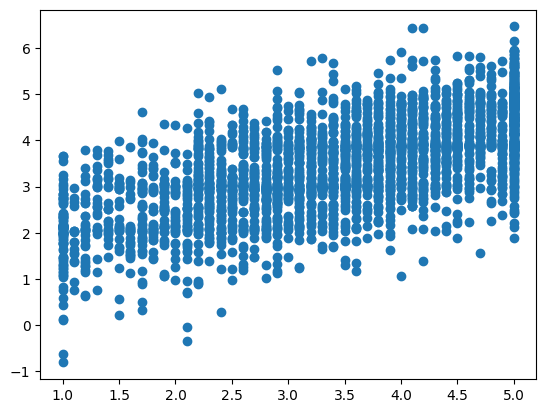

In [45]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)
plt.show()

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


In [46]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} ")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} ")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)}")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")


MAE:
0.71 

MSE:
0.8 

RMSE:
0.9

R-squared:
0.39


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_15190/2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


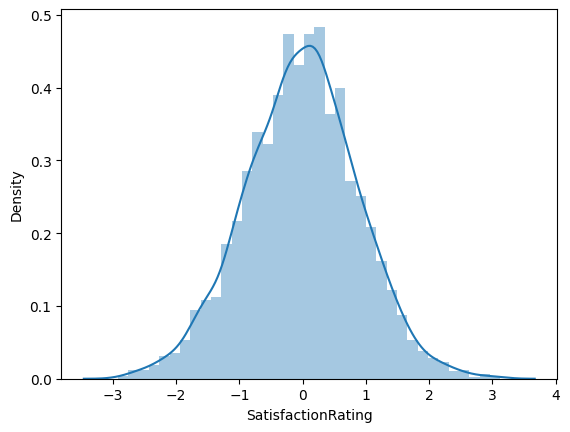

In [47]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

In [48]:
X.columns

Index(['StudentLevel', 'SessionDate', 'TotalPrompts', 'AI_AssistanceLevel',
       'UsedAgain', 'Discipline_Biology', 'Discipline_Business',
       'Discipline_Computer Science', 'Discipline_Engineering',
       'Discipline_History',
       ...
       'SessionLengthMin_94.5', 'SessionLengthMin_98.96',
       'SessionLengthMin_99.57', 'SessionLengthMin_110.81',
       'TaskType_Brainstorming', 'TaskType_Coding', 'TaskType_Homework Help',
       'TaskType_Research', 'TaskType_Studying', 'TaskType_Writing'],
      dtype='object', length=4100)


<div style="border: 4px solid #0f766e; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    OBSERVATION
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <b>R Squared is 0.43.</b> which does not look that good as it should be close to 0.9, 
    But there is a  good sign because the model is not strongly unbalanced in one direction.
    There are a few extreme outliers on both sides.
    If the model was perfect, all points would lie on a straight diagonal line.

  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> Using the model in practice</b>
</h3>
</div>


<h3 style='color:orange'>
  <b> I did not create a new input row for this model because the dataset is synthetic and the values would not be meaningful.
</b>
</h3>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #0f766e; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> AI Usage</b>
</h3>
</div>


<h3>
<strong style='color:orange ;'>Yes (for html and style)
 </strong>
</h3>




---

<div style="border: 4px solid #0f766e; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px; max-width: 100%; box-sizing: border-box; word-wrap: break-word;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    CONCLUSION:
  </h2>
  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The model predicts <strong style="color:#0f766e;">student satisfaction scores</strong> from AI assistant usage data. The dataset has <strong style="color:#0f766e;">10,000 rows and 11 columns</strong>, all synthetic, so the results are for practice only and do not reflect real student behavior.</li>
    <br>
    <li>Linear Regression scored <strong style="color:#0f766e;">R² of 0.39</strong> on the full dataset. Filtering by TaskType improved it slightly. <strong style="color:#0f766e;">Studying rows gave 0.47</strong>, Writing gave 0.44, and Homework Help dropped to 0.38. The model performs differently depending on task type, and training on all task types together mixes those differences.</li>
    <br>
    <li>Random Forest Regression scored <strong style="color:#0f766e;">R² of 0.43</strong>. It did not improve much over Linear Regression. A non-linear model did not help here, which suggests the relationships between features and satisfaction scores are not strongly non-linear.</li>
    <br>
    <li>An R² of 0.43 means the model explains <strong style="color:#0f766e;">43% of the variation</strong> in satisfaction scores. The scatter plot shows the model is not strongly onesided in one direction, but there are outliers on both sides.</li>
    <br>
    <li>To improve the score, you would need <strong style="color:#0f766e;">more informative features</strong>, a larger real-world dataset, or better features.</li>
  </ul>
</div>

---